<a href="https://colab.research.google.com/github/bibekchaudhary-blip/Neural-Network/blob/main/SMS_Spam_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TECH 405 RNN Hackathon: SMS spam detection with an LSTM

**Task:** classify a text message as **ham** (normal) or **spam** (2 classes).
**Dataset:** SMS Spam Collection, 5,572 labelled messages.
**Model:** word embedding → `nn.LSTM` → `nn.Linear`, written in PyTorch and trained from scratch.

| | Accuracy |
|---|---|
| Baseline (always guess "ham") | 86.6% |
| Target (full marks) | 96% |

* No pretrained models or embeddings.
* Fixed, stratified **80/20 train/test split** (`random_state=42`).
* The **test set is used once**, in Cell 13. The best epoch is chosen with a validation set taken from the training 80%.

**Running in Google Colab:** `Runtime → Run all`. Everything needed (PyTorch, pandas, scikit-learn, matplotlib) is already installed in Colab. A CPU runtime is enough; a GPU (`Runtime → Change runtime type → T4 GPU`) is optional.

In [1]:
# Cell 1: Imports and configuration
import copy
import random
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, TensorDataset

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data settings ----
DATA_URL = ("https://raw.githubusercontent.com/mohitgupta-omg/"
            "Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv")
TEST_SIZE = 0.20      # fixed 80/20 train/test split
VAL_SIZE = 0.10       # 10% of the TRAINING data, used to pick the best epoch
MAXLEN = 50           # each message becomes 50 tokens (about 99% of messages are shorter)
MIN_FREQ = 2          # a word must appear at least twice in training to get its own ID

# ---- Model settings ----
EMBED_DIM = 64
HIDDEN_DIM = 64
NUM_CLASSES = 2       # ham (0), spam (1)
DROPOUT = 0.3

# ---- Training settings ----
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EPOCHS = 10
GRAD_CLIP = 1.0

# From the assignment sheet, used only for the final comparison
BASELINE_ACC = 0.866
TARGET_ACC = 0.96

SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_DIR.mkdir(exist_ok=True)

print("PyTorch version:", torch.__version__)
print("Device:         ", DEVICE)

PyTorch version: 2.11.0+cu130
Device:          cuda


**Why these values.** They were fixed before training and not changed based on test results.
* `MAXLEN = 50`: text messages are short (median about 13 words), so 50 tokens keeps almost every message whole. Cell 8 prints the exact share.
* `MIN_FREQ = 2`: words seen only once become `<unk>`, which stops the model memorising one-off phone numbers.
* `EMBED_DIM`, `HIDDEN_DIM = 64`: the dataset is small (about 3,700 training messages), so a small LSTM is enough and overfits less.
* Adam with learning rate 0.001, batch size 32, dropout 0.3 and gradient clipping 1.0 are standard, stable settings for LSTMs.
* `EPOCHS = 10`, and the epoch with the **lowest validation loss** is kept.

In [2]:
# Cell 2: Load the SMS Spam dataset
df = pd.read_csv(DATA_URL, encoding="latin-1")[["v1", "v2"]]   # v1 = ham/spam, v2 = message text
df = df.rename(columns={"v1": "label_text", "v2": "text"})
RAW_SHAPE = df.shape

print("Dataset shape (rows, columns):", df.shape)
display(df.head())

counts = df["label_text"].value_counts()
print("Class distribution:")
display(pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(2)}))

Dataset shape (rows, columns): (5572, 2)


,label_text,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Class distribution:


,count,percent
label_text,,
ham,4825,86.59
spam,747,13.41


## Cell 3: Why this is a sequence problem

A text message is a **sequence of words**, and the meaning depends on their order and context.
"Call now to claim your prize" is typical spam, while "I'll call you now about the prize draw" from a friend is harmless, even though the two share words such as *call*, *now* and *prize*.

An **LSTM** reads the message one word at a time and keeps a memory (hidden and cell state) of what it has read so far.
By the last word, that memory summarises the whole message in order, which is what the classifier uses to decide ham or spam.

In [3]:
# Cell 4: Convert labels (ham -> 0, spam -> 1)
df["label"] = df["label_text"].map({"ham": 0, "spam": 1})
assert df["label"].notna().all()
df["label"] = df["label"].astype(int)

display(df[["label_text", "label", "text"]].head(6))
print(df.groupby(["label_text", "label"]).size().rename("count").to_string())

,label_text,label,text
0,ham,0,"Go until jurong point, crazy.. Available only ..."
1,ham,0,Ok lar... Joking wif u oni...
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,0,U dun say so early hor... U c already then say...
4,ham,0,"Nah I don't think he goes to usf, he lives aro..."
5,spam,1,FreeMsg Hey there darling it's been 3 week's n...


label_text  label
ham         0        4825
spam        1         747


## Cell 5: Remove duplicate messages

Many spam messages were sent more than once, so the same text appears several times. If one copy went into training and another into the test set, the test would include messages the model had already seen. Duplicates are removed **before** splitting.

In [4]:
# Cell 5: Remove duplicate messages (prevents train/test leakage)
n_before = len(df)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Removed {n_before - len(df):,} duplicates -> {len(df):,} unique messages")
print(df["label_text"].value_counts().to_string())
print(f"Ham share after removing duplicates: {(df['label'] == 0).mean():.1%}")

Removed 403 duplicates -> 5,169 unique messages
label_text
ham     4516
spam     653
Ham share after removing duplicates: 87.4%


In [5]:
# Cell 6: Fixed 80/20 train/test split, then a validation set from the training part
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=SEED, stratify=df["label"])
train_df, val_df = train_test_split(train_df, test_size=VAL_SIZE, random_state=SEED, stratify=train_df["label"])

for name, part in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name:<11} {len(part):>5,} messages ({len(part) / len(df):.0%})   spam share {part['label'].mean():.1%}")

Train       3,721 messages (72%)   spam share 12.6%
Validation    414 messages (8%)   spam share 12.6%
Test        1,034 messages (20%)   spam share 12.7%


## Cell 7: Tokenise and build the vocabulary

Messages are lower-cased and split into words. Numbers, `£`/`$` and `!`/`?` are kept as tokens because spam often uses them ("WIN £1000!!").
The vocabulary comes from the **training messages only**. Index 0 is `<pad>` and index 1 is `<unk>` (unknown word).

In [6]:
# Cell 7: Tokeniser and vocabulary (training split only)
def tokenize(text):
    return re.findall(r"[a-z0-9£$€']+|[!?]", text.lower())

print("Example:", tokenize("WINNER!! Claim your £900 prize, call 09061701461 now"))

word_counts = Counter()
for text in train_df["text"]:
    word_counts.update(tokenize(text))

itos = ["<pad>", "<unk>"] + sorted(w for w, c in word_counts.items() if c >= MIN_FREQ)
stoi = {w: i for i, w in enumerate(itos)}
PAD_IDX, UNK_IDX = 0, 1

print(f"Different words in training messages: {len(word_counts):,}")
print(f"Vocabulary (seen at least {MIN_FREQ} times):  {len(itos):,} including <pad> and <unk>")
print("Most common words:", [w for w, _ in word_counts.most_common(15)])

Example: ['winner', '!', '!', 'claim', 'your', '£900', 'prize', 'call', '09061701461', 'now']
Different words in training messages: 7,315
Vocabulary (seen at least 2 times):  3,274 including <pad> and <unk>
Most common words: ['i', 'you', 'to', '?', '!', 'a', 'the', 'u', 'and', 'in', 'is', 'me', 'my', 'for', 'your']


## Cell 8: Turn messages into fixed-length sequences

Each message becomes a list of word IDs of length `MAXLEN`. Longer messages keep their **first** 50 words, since spam usually announces itself early ("FREE entry…", "WINNER!!"). Shorter ones are padded with 0. The real length is stored so the LSTM can stop at the last real word (`pack_padded_sequence`) instead of reading padding.

In [7]:
# Cell 8: Encode, truncate/pad to MAXLEN, and create DataLoaders
def encode(text):
    ids = [stoi.get(t, UNK_IDX) for t in tokenize(text)]
    n_words = len(ids)
    ids = ids[:MAXLEN]
    length = max(len(ids), 1)                       # an empty message still gets length 1
    return ids + [PAD_IDX] * (MAXLEN - len(ids)), length, n_words


def make_tensors(frame):
    enc = [encode(t) for t in frame["text"]]
    X = torch.tensor([e[0] for e in enc], dtype=torch.long)
    lengths = torch.tensor([e[1] for e in enc], dtype=torch.long)
    y = torch.tensor(frame["label"].values, dtype=torch.long)
    return X, lengths, y, np.array([e[2] for e in enc])


X_train, len_train, y_train, words_train = make_tensors(train_df)
X_val, len_val, y_val, _ = make_tensors(val_df)
X_test, len_test, y_test, _ = make_tensors(test_df)

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(TensorDataset(X_train, len_train, y_train), batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(TensorDataset(X_val, len_val, y_val), batch_size=256)
test_loader = DataLoader(TensorDataset(X_test, len_test, y_test), batch_size=256)

print(f"Median training message length: {np.median(words_train):.0f} words")
print(f"Training messages longer than MAXLEN={MAXLEN}: {(words_train > MAXLEN).mean():.1%} (these are cut)")
print(f"Batches per epoch: {len(train_loader)}")

Median training message length: 12 words
Training messages longer than MAXLEN=50: 1.0% (these are cut)
Batches per epoch: 117


In [8]:
# Cell 9: Snapshot 1, data and shapes
def save_text_snapshot(text, caption, filename):
    """Draw printed text and a caption into a PNG in screenshots/."""
    height = 0.17 * (text.count("\n") + 1) + 1.0
    fig = plt.figure(figsize=(11, height))
    body = fig.text(0.01, 0.98, text, family="monospace", fontsize=9, va="top")
    fig.canvas.draw()
    bottom = body.get_window_extent().transformed(fig.transFigure.inverted()).y0
    fig.text(0.01, bottom - 0.25 / height, caption, fontsize=10, style="italic", va="top", wrap=True)
    fig.savefig(SCREENSHOT_DIR / filename, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"\nSaved screenshots/{filename}")


ex_text = train_df[train_df["label"] == 1]["text"].iloc[0]
ex_ids, ex_len, _ = encode(ex_text)
snapshot_1 = "\n".join([
    f"SMS Spam Collection loaded:  {RAW_SHAPE[0]:,} messages, columns v1 (label) and v2 (text)",
    f"After removing duplicates:   {len(df):,} messages  (ham -> 0, spam -> 1, spam share {df['label'].mean():.1%})",
    "",
    "Split (stratified, random_state=42)    X (word IDs)      lengths     y (labels)",
    f"  train       {len(train_df):>5,} messages       {str(tuple(X_train.shape)):<17} {str(tuple(len_train.shape)):<11} {tuple(y_train.shape)}",
    f"  validation  {len(val_df):>5,} messages       {str(tuple(X_val.shape)):<17} {str(tuple(len_val.shape)):<11} {tuple(y_val.shape)}",
    f"  test        {len(test_df):>5,} messages       {str(tuple(X_test.shape)):<17} {str(tuple(len_test.shape)):<11} {tuple(y_test.shape)}",
    "",
    f"Each message = a sequence of MAXLEN={MAXLEN} word IDs, vocabulary of {len(itos):,}",
    f"One training batch: X {(BATCH_SIZE, MAXLEN)}, y {(BATCH_SIZE,)}",
    "",
    "Example spam message from the training set:",
    "  text:   " + ex_text[:90] + ("..." if len(ex_text) > 90 else ""),
    "  tokens: " + " ".join(tokenize(ex_text)[:12]),
    "  IDs:    " + str(ex_ids[:12]),
])
print(snapshot_1)
save_text_snapshot(snapshot_1,
    "Snapshot 1. SMS messages with ham/spam labels, the fixed 80/20 split (validation taken from the training part) "
    f"and tensor shapes: every message is a sequence of {MAXLEN} word IDs.",
    "01_data_shapes.png")

SMS Spam Collection loaded:  5,572 messages, columns v1 (label) and v2 (text)
After removing duplicates:   5,169 messages  (ham -> 0, spam -> 1, spam share 12.6%)

Split (stratified, random_state=42)    X (word IDs)      lengths     y (labels)
  train       3,721 messages       (3721, 50)        (3721,)     (3721,)
  validation    414 messages       (414, 50)         (414,)      (414,)
  test        1,034 messages       (1034, 50)        (1034,)     (1034,)

Each message = a sequence of MAXLEN=50 word IDs, vocabulary of 3,274
One training batch: X (32, 50), y (32,)

Example spam message from the training set:
  text:   Hi. Customer Loyalty Offer:The NEW Nokia6650 Mobile from ONLY å£10 at TXTAUCTION! Txt word...
  tokens: hi customer loyalty offer the new nokia6650 mobile from only £10 at
  IDs:    [1387, 822, 1743, 2029, 2810, 1977, 1995, 1873, 1208, 2051, 3252, 401]

Saved screenshots/01_data_shapes.png


## Cell 10: The model (Snapshot 2)

`word IDs (batch, 50)` → `nn.Embedding` (batch, 50, 64) → `nn.LSTM` → final hidden state (batch, 64) → `nn.Dropout` → `nn.Linear` → 2 scores (ham, spam).
All weights, including the word embeddings, start random and are learned only from the training messages.

In [9]:
# Cell 10: Model definition (nn.LSTM -> nn.Linear), Snapshot 2
class SpamLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))                     # (batch, MAXLEN, embed_dim)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                                 # h_n: (1, batch, hidden_dim)
        return self.fc(self.dropout(h_n[-1]))                           # (batch, 2)


model = SpamLSTM(len(itos), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, PAD_IDX, DROPOUT).to(DEVICE)

xb, lb = X_train[:BATCH_SIZE], len_train[:BATCH_SIZE]
model.eval()
with torch.no_grad():
    out = model(xb.to(DEVICE), lb)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

snapshot_2 = "\n".join([
    str(model), "",
    f"Trainable parameters: {n_params:,} (trained from scratch, no pretrained weights)",
    f"Shape check: input {tuple(xb.shape)} word IDs -> output {tuple(out.shape)} class scores",
    f"Loss: CrossEntropyLoss | Optimiser: Adam (lr={LEARNING_RATE}) | batch {BATCH_SIZE} | "
    f"dropout {DROPOUT} | gradient clipping {GRAD_CLIP}",
])
print(snapshot_2)
save_text_snapshot(snapshot_2,
    "Snapshot 2. The model: learned word embeddings feed an nn.LSTM; its final hidden state goes through "
    "nn.Linear to give one score for ham and one for spam.",
    "02_model.png")

SpamLSTM(
  (embedding): Embedding(3274, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

Trainable parameters: 242,946 (trained from scratch, no pretrained weights)
Shape check: input (32, 50) word IDs -> output (32, 2) class scores
Loss: CrossEntropyLoss | Optimiser: Adam (lr=0.001) | batch 32 | dropout 0.3 | gradient clipping 1.0

Saved screenshots/02_model.png


## Cell 11: Train the model

Each epoch trains on all training batches, then measures loss and accuracy on the **validation** set. The weights from the epoch with the **lowest validation loss** are kept (loss is a finer signal than accuracy on a validation set of about 400 messages). The test set is not used here.

In [10]:
# Cell 11: Training loop (validation picks the best epoch; test set untouched)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def run_epoch(loader, train=False, batch_losses=None):
    model.train(train)
    total_loss, correct, count = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, lb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb, lb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
                batch_losses.append(loss.item())
            total_loss += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            count += len(yb)
    return total_loss / count, correct / count


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
batch_losses = []
best_val_loss, best_epoch, best_state = float("inf"), 0, None

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True, batch_losses=batch_losses)
    va_loss, va_acc = run_epoch(val_loader)
    for k, v in zip(history, (tr_loss, tr_acc, va_loss, va_acc)):
        history[k].append(v)
    note = ""
    if va_loss < best_val_loss:
        best_val_loss, best_epoch = va_loss, epoch
        best_state = copy.deepcopy(model.state_dict())
        note = "  <- best so far"
    print(f"Epoch {epoch:>2}/{EPOCHS} | train loss {tr_loss:.4f}, acc {tr_acc:.2%} | "
          f"val loss {va_loss:.4f}, acc {va_acc:.2%} | {time.time() - start:.1f}s{note}")

print(f"\nBest epoch: {best_epoch} (validation loss {best_val_loss:.4f}, "
      f"validation accuracy {history['val_acc'][best_epoch - 1]:.2%}). These weights are used for the test.")

Epoch  1/10 | train loss 0.4164, acc 83.02% | val loss 0.2330, acc 89.61% | 2.8s  <- best so far
Epoch  2/10 | train loss 0.1986, acc 92.64% | val loss 0.1295, acc 95.41% | 0.8s  <- best so far
Epoch  3/10 | train loss 0.1111, acc 96.56% | val loss 0.0846, acc 97.10% | 0.8s  <- best so far
Epoch  4/10 | train loss 0.0769, acc 97.90% | val loss 0.0724, acc 98.07% | 0.8s  <- best so far
Epoch  5/10 | train loss 0.0550, acc 98.36% | val loss 0.0709, acc 98.07% | 0.8s  <- best so far
Epoch  6/10 | train loss 0.0523, acc 98.47% | val loss 0.0793, acc 98.07% | 0.8s
Epoch  7/10 | train loss 0.0348, acc 99.01% | val loss 0.0708, acc 98.55% | 0.8s  <- best so far
Epoch  8/10 | train loss 0.0444, acc 98.71% | val loss 0.0826, acc 97.83% | 1.0s
Epoch  9/10 | train loss 0.0290, acc 99.27% | val loss 0.0697, acc 98.79% | 1.1s  <- best so far
Epoch 10/10 | train loss 0.0251, acc 99.25% | val loss 0.0590, acc 98.79% | 1.1s  <- best so far

Best epoch: 10 (validation loss 0.0590, validation accuracy 9

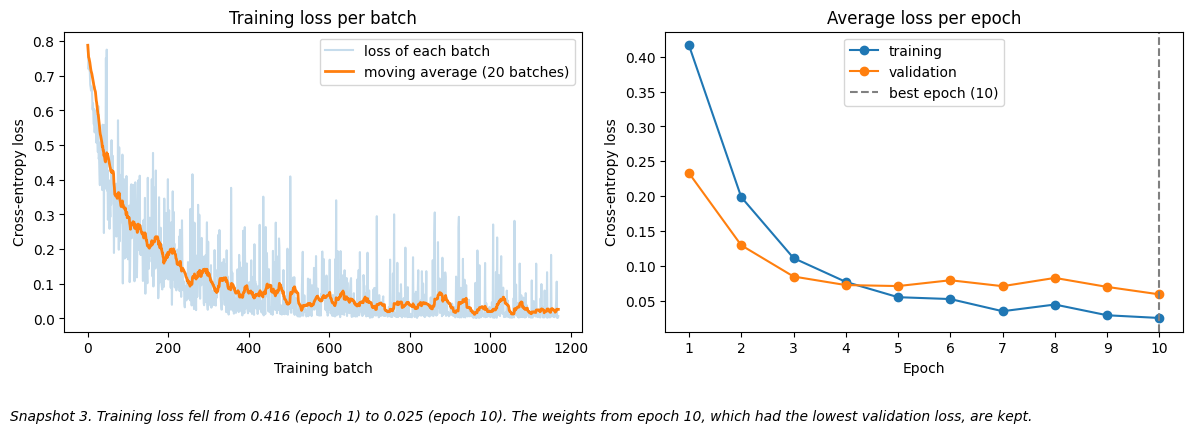

In [11]:
# Cell 12: Training loss plot, Snapshot 3
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
window = 20
axes[0].plot(batch_losses, alpha=0.25, label="loss of each batch")
axes[0].plot(pd.Series(batch_losses).rolling(window, min_periods=1).mean(), linewidth=2,
             label=f"moving average ({window} batches)")
axes[0].set(title="Training loss per batch", xlabel="Training batch", ylabel="Cross-entropy loss")
axes[0].legend()

ep = range(1, EPOCHS + 1)
axes[1].plot(ep, history["train_loss"], marker="o", label="training")
axes[1].plot(ep, history["val_loss"], marker="o", label="validation")
axes[1].axvline(best_epoch, color="grey", linestyle="--", label=f"best epoch ({best_epoch})")
axes[1].set(title="Average loss per epoch", xlabel="Epoch", ylabel="Cross-entropy loss", xticks=list(ep))
axes[1].legend()

caption_3 = (f"Snapshot 3. Training loss fell from {history['train_loss'][0]:.3f} (epoch 1) to "
             f"{history['train_loss'][-1]:.3f} (epoch {EPOCHS}). The weights from epoch {best_epoch}, "
             "which had the lowest validation loss, are kept.")
fig.text(0.01, 0.01, caption_3, fontsize=10, style="italic", wrap=True)
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(SCREENSHOT_DIR / "03_training_loss.png", dpi=150, facecolor="white")
plt.show()

## Cell 13: Final evaluation on the test set (Snapshot 4)

The **only** cell that uses the test set. It loads the best-epoch weights, predicts every test message once, and compares accuracy with the baseline and target. Because 87% of messages are ham, spam precision and recall are printed too: they show how well spam itself is caught.

Test accuracy 98.07% on 1,034 unseen messages vs baseline 86.6% and target 96%: it reaches the target.
(Always guessing 'ham' on this test set would score 87.3%.)

              precision    recall  f1-score   support

         ham      0.985     0.993     0.989       903
        spam      0.951     0.893     0.921       131

    accuracy                          0.981      1034
   macro avg      0.968     0.943     0.955      1034
weighted avg      0.980     0.981     0.980      1034

           pred ham  pred spam
true ham        897          6
true spam        14        117


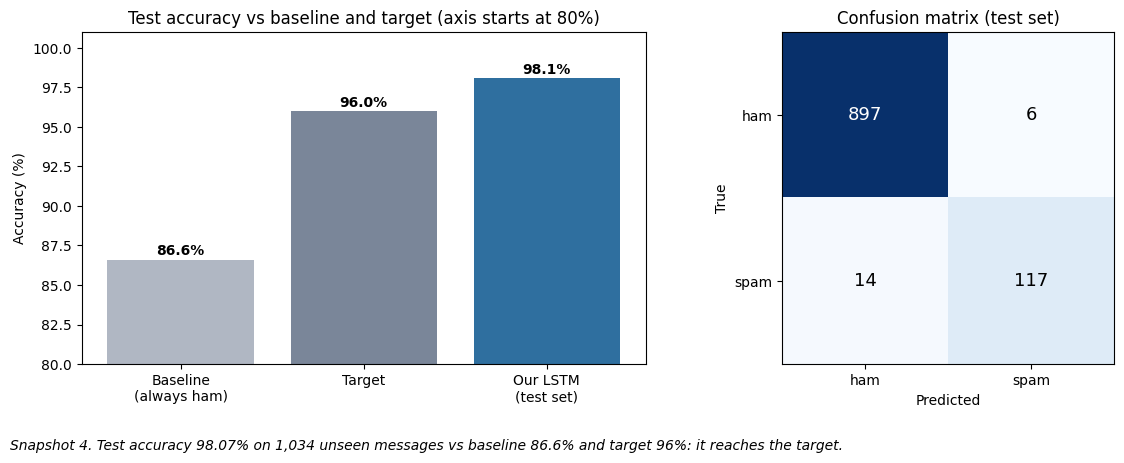

In [12]:
# Cell 13: Final test accuracy (only use of the test set), Snapshot 4
model.load_state_dict(best_state)
model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, lb, yb in test_loader:
        preds.append(model(xb.to(DEVICE), lb).argmax(1).cpu())
        trues.append(yb)
y_pred = torch.cat(preds).numpy()
y_true = torch.cat(trues).numpy()

test_acc = (y_pred == y_true).mean()
test_majority = max(y_true.mean(), 1 - y_true.mean())
cm = confusion_matrix(y_true, y_pred)

if test_acc >= TARGET_ACC:
    verdict = "reaches the target"
elif test_acc > BASELINE_ACC:
    verdict = "beats the baseline but is below the target"
else:
    verdict = "is not above the baseline, so the model did not learn"
result_line = (f"Test accuracy {test_acc:.2%} on {len(y_true):,} unseen messages vs baseline "
               f"{BASELINE_ACC:.1%} and target {TARGET_ACC:.0%}: it {verdict}.")

print(result_line)
print(f"(Always guessing 'ham' on this test set would score {test_majority:.1%}.)\n")
print(classification_report(y_true, y_pred, target_names=["ham", "spam"], digits=3))
print(pd.DataFrame(cm, index=["true ham", "true spam"], columns=["pred ham", "pred spam"]).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.2, 1]})
names = ["Baseline\n(always ham)", "Target", "Our LSTM\n(test set)"]
vals = [BASELINE_ACC * 100, TARGET_ACC * 100, test_acc * 100]
bars = ax1.bar(names, vals, color=["#b0b7c3", "#7a8699", "#2f6f9f"])
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")
ax1.set(ylim=(80, 101), ylabel="Accuracy (%)", title="Test accuracy vs baseline and target (axis starts at 80%)")

ax2.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
ax2.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["ham", "spam"], yticklabels=["ham", "spam"],
        xlabel="Predicted", ylabel="True", title="Confusion matrix (test set)")

fig.text(0.01, 0.01, "Snapshot 4. " + result_line, fontsize=10, style="italic", wrap=True)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(SCREENSHOT_DIR / "04_test_accuracy.png", dpi=150, facecolor="white")
plt.show()

In [13]:
# Cell 14 (optional): Try the model on your own messages
def predict(text):
    ids, length, _ = encode(text)
    with torch.no_grad():
        logits = model(torch.tensor([ids]).to(DEVICE), torch.tensor([length]))
    p_spam = torch.softmax(logits, dim=1)[0, 1].item()
    return ("SPAM" if p_spam >= 0.5 else "ham"), p_spam


for msg in ["Congratulations! You have won a £1000 prize. Call 09061701461 to claim now!",
            "Hey, are we still meeting at the library at 5?",
            "URGENT! Your mobile number has been selected for a free reward. Text WIN to 87121",
            "Can you send me the notes from today's lecture?"]:
    label, p = predict(msg)
    print(f"{label:<5} P(spam) = {p:.2f}   {msg}")

SPAM  P(spam) = 1.00   Congratulations! You have won a £1000 prize. Call 09061701461 to claim now!
ham   P(spam) = 0.00   Hey, are we still meeting at the library at 5?
SPAM  P(spam) = 1.00   URGENT! Your mobile number has been selected for a free reward. Text WIN to 87121
ham   P(spam) = 0.00   Can you send me the notes from today's lecture?


In [15]:
# Cell 15: Download the four snapshots (Colab)
import shutil
shutil.make_archive("screenshots", "zip", SCREENSHOT_DIR)
try:
    from google.colab import files
    files.download("screenshots.zip")
except ImportError:
    print("Not running in Colab: the images are in the screenshots/ folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Report checklist
* Dataset + why it is a sequence problem: Cell 3.
* Snapshots 1 to 4: `screenshots/01_data_shapes.png`, `02_model.png`, `03_training_loss.png`, `04_test_accuracy.png` (each has its caption).
* One line, accuracy vs baseline and target: the `result_line` printed by Cell 13.
* One honest sentence: write it from Cells 11 and 13 (for example, whether spam recall is lower than ham recall, or whether validation loss rose in later epochs).